# **Librerías**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io
from scipy.fft import fft, fftfreq, fftshift, ifft
pi=np.pi

# **Señales y Espectros de Fourier**

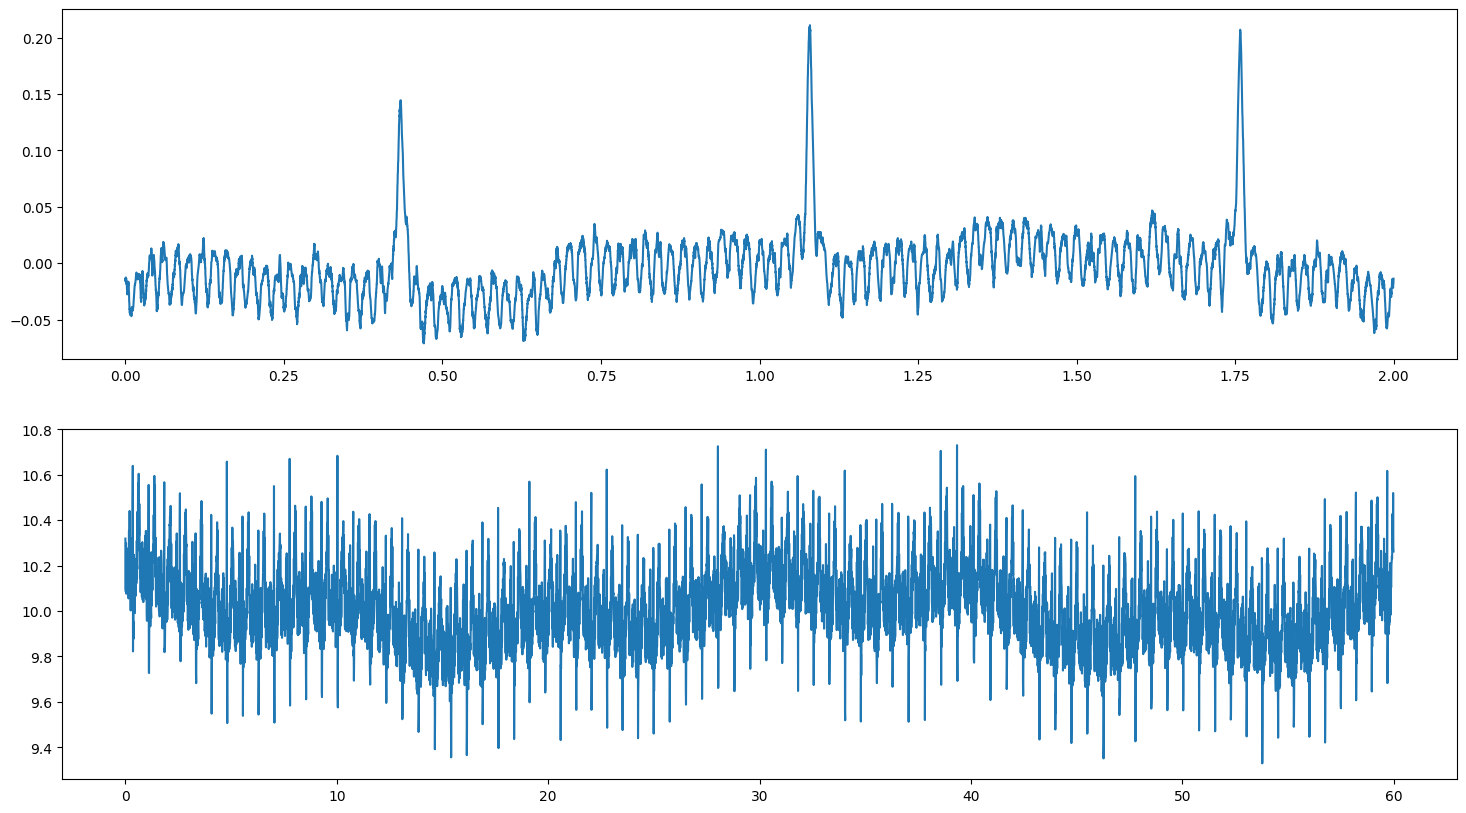

In [ ]:
datos1 = scipy.io.loadmat('/content/drive/MyDrive/ColabNotebooks/FAYD/ecg_noisy.mat')
datos2 = scipy.io.loadmat('/content/drive/MyDrive/ColabNotebooks/FAYD/ecg_noisy2.mat')

t1 = datos1['time_vector'][0]+1.12925
ecg1 = datos1['data_vector'][0]
t2 = datos2['t'][0]
ecg2 = datos2['ecg'][0]
plt.figure(figsize=(18,10))
plt.subplot(2,1,1)
#plt.xlim(-0.5,0.5)
plt.plot(t1,ecg1)
plt.subplot(2,1,2)
#plt.xlim(20,30)
plt.plot(t2,ecg2)

<StemContainer object of 3 artists>

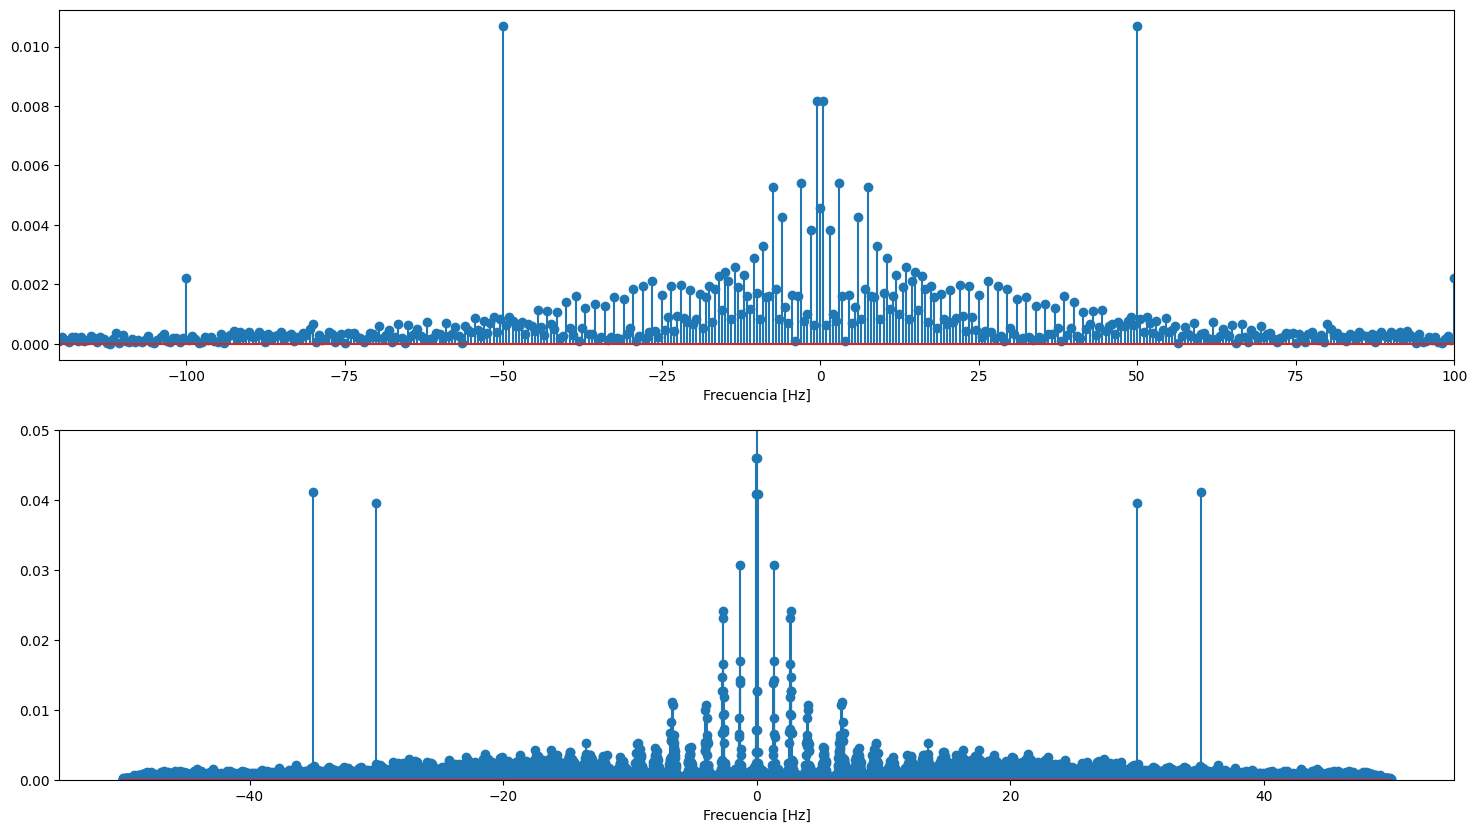

In [ ]:
N1 = len(ecg1)
N2 = len(ecg2)
fs1 = N1/t1[-1]
fs2 = N2/t2[-1]

x1_jΩ = fft(ecg1)
Ω1 = fftfreq(N1,1/fs1)
x2_jΩ = fft(ecg2)
Ω2 = fftfreq(N2,1/fs2)

plt.figure(figsize=(18,10))
plt.subplot(2,1,1)
plt.xlabel('Frecuencia [Hz]')
plt.xlim(-120,100)
plt.stem(fftshift(Ω1),fftshift(abs(x1_jΩ))/N1)
plt.subplot(2,1,2)
plt.xlabel('Frecuencia [Hz]')
#plt.xlim(0,30)
plt.ylim(0,0.05)
plt.stem(fftshift(Ω2),fftshift(abs(x2_jΩ))/N2)

# **Propuesta de Filtros**

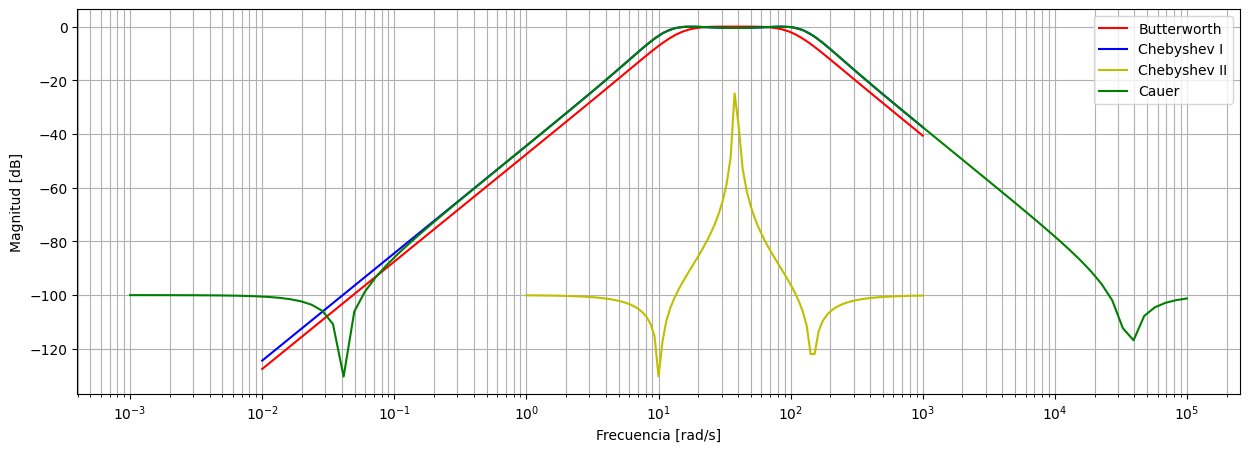

In [ ]:
ΩL=2.15*2*pi
ΩH=17.5*2*pi
N=2
rp=0.5
rs=100
tipo='bandpass'

b_butt, a_butt = signal.butter(N,  [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)
b_cheby1, a_cheby1 = signal.cheby1(N, rp, [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)
b_cheby2, a_cheby2 = signal.cheby2(N, rs, [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)
b_cauer, a_cauer = signal.ellip(N, rp, rs, [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)

H_butt = signal.TransferFunction(b_butt, a_butt)
H_cheby1 = signal.TransferFunction(b_cheby1, a_cheby1)
H_cheby2 = signal.TransferFunction(b_cheby2, a_cheby2)
H_cauer = signal.TransferFunction(b_cauer, a_cauer)

frec_butt,magnitud_butt,fase_butt=signal.bode(H_butt)
frec_cheby1,magnitud_cheby1,fase_cheby1=signal.bode(H_cheby1)
frec_cheby2,magnitud_cheby2,fase_cheby2=signal.bode(H_cheby2)
frec_cauer,magnitud_cauer,fase_cauer=signal.bode(H_cauer)

plt.figure(figsize=(15,5))
# plt.subplot(1,2,1)
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
# plt.ylim(-1,1)
# plt.xlim(2,500)
plt.semilogx(frec_butt,magnitud_butt,color='r', label='Butterworth')
plt.semilogx(frec_cheby1,magnitud_cheby1,color='b', label='Chebyshev I')
plt.semilogx(frec_cheby2,magnitud_cheby2,color='y', label='Chebyshev II')
plt.semilogx(frec_cauer,magnitud_cauer,color='g', label='Cauer')
plt.grid(True, which="both")
plt.legend()
# plt.subplot(1,2,2)
# plt.ylabel('Fase [rad]')
# plt.xlabel('Frecuencia [rad/s]')
# plt.semilogx(frec_butt,fase_butt,color='r')
# plt.semilogx(frec_cheby1,fase_cheby1,color='b')
# plt.semilogx(frec_cheby2,fase_cheby2,color='y')
# plt.semilogx(frec_cauer,fase_cauer,color='g')
# plt.grid(True, which="both")

In [ ]:
print(f'Magnitud [dB]:',magnitud_cheby1[(frec_cheby1>7.3) & (frec_cheby1<7.7)])
print(f'Magnitud [dB]:',magnitud_cheby1[(frec_cheby1>119) & (frec_cheby1<124)])

Magnitud [dB]: [-8.07391056]
Magnitud [dB]: [-1.25935129]


# **Filtrado de Señales**

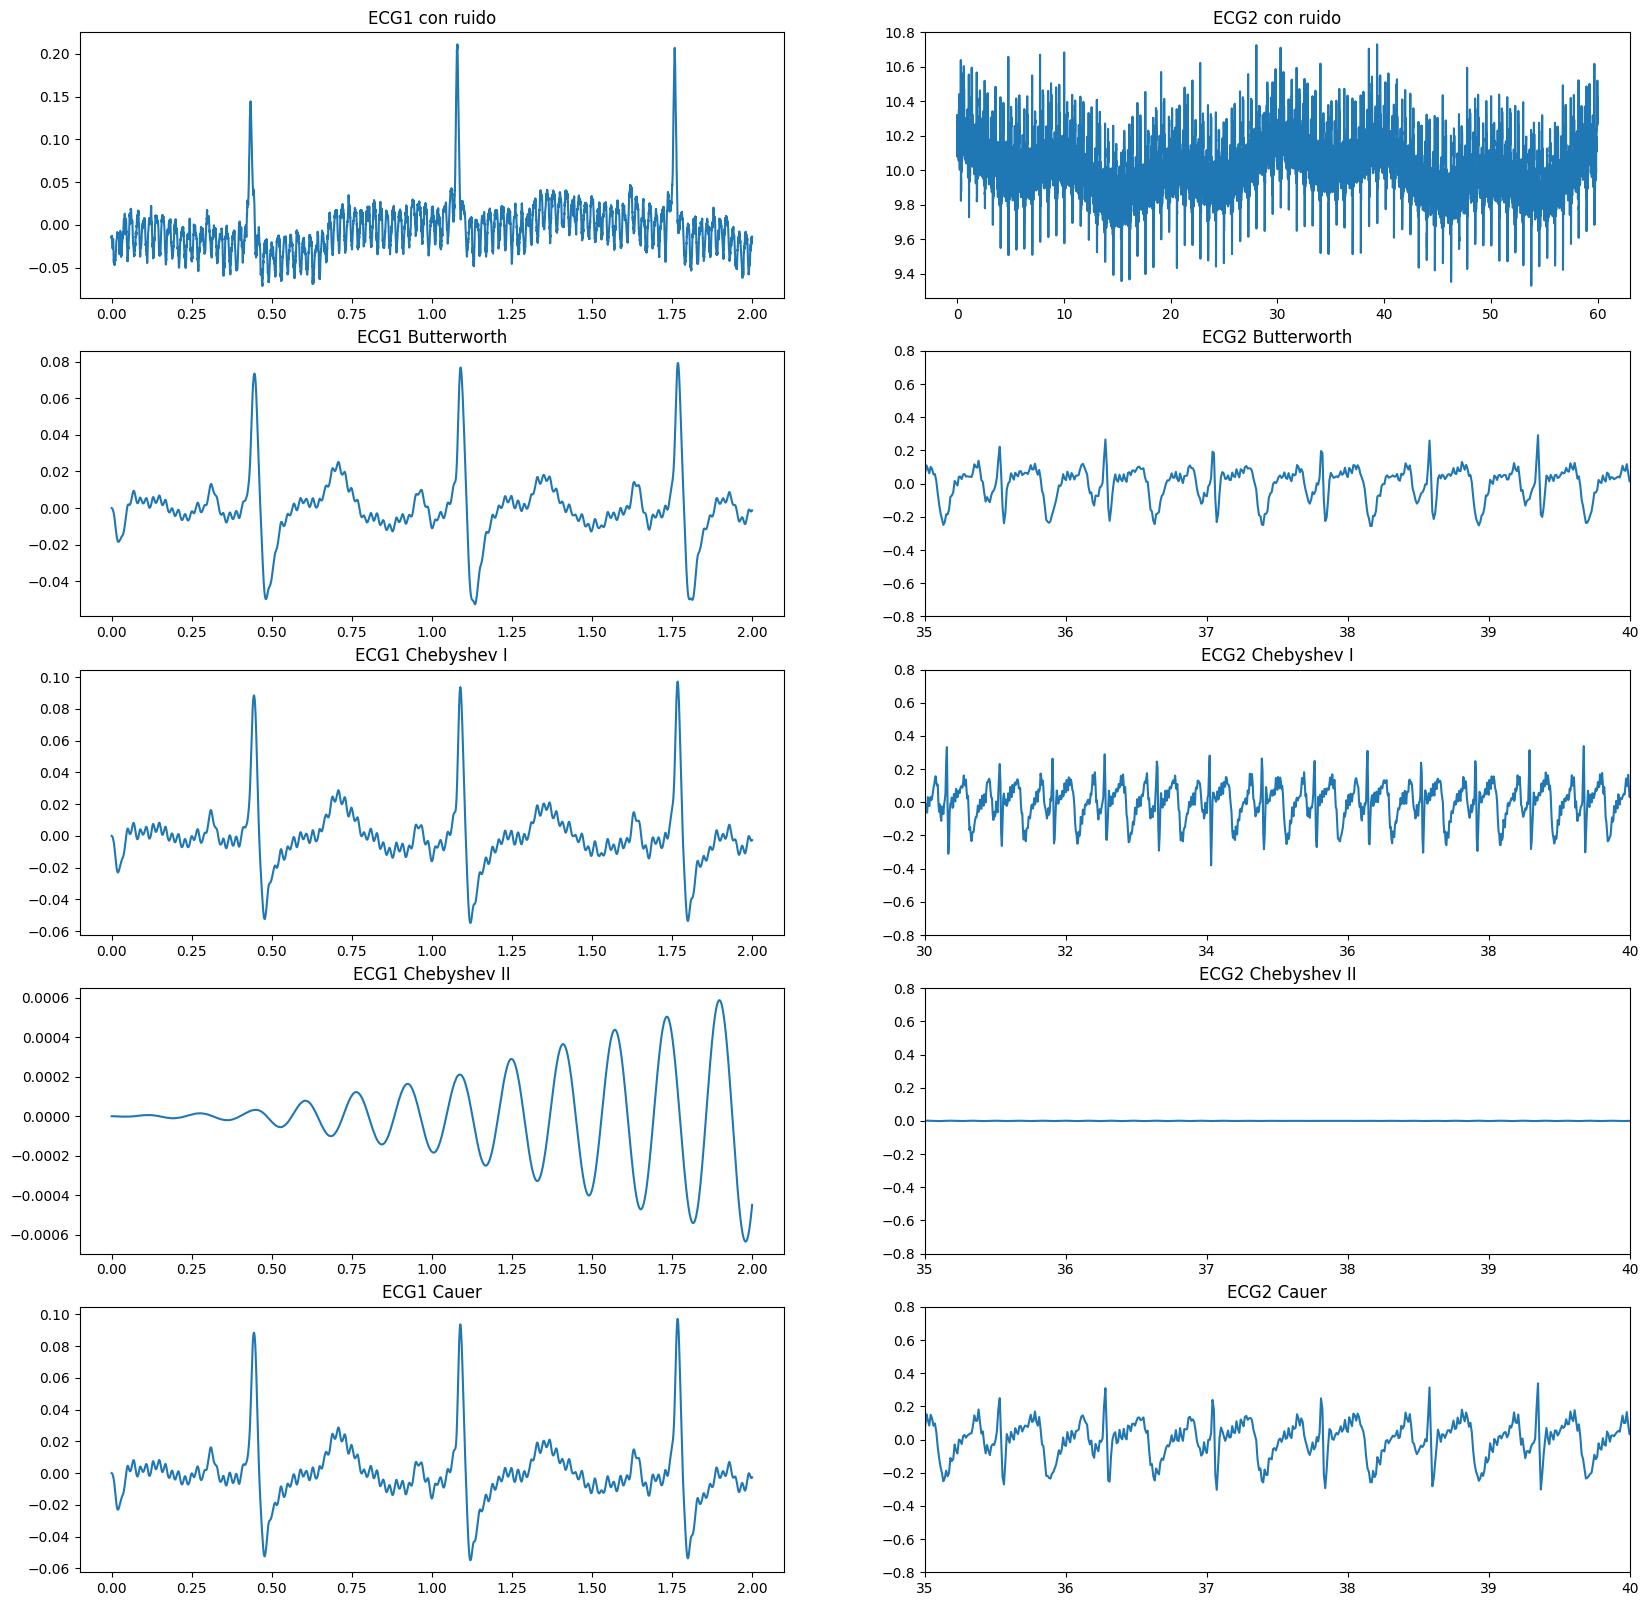

In [ ]:
t1_butt, ecg1_butt, _ = signal.lsim(H_butt,ecg1,t1)
t2_butt, ecg2_butt, _ = signal.lsim(H_butt,ecg2,t2)
t1_cheby1, ecg1_cheby1, _ = signal.lsim(H_cheby1,ecg1,t1)
t2_cheby1, ecg2_cheby1, _ = signal.lsim(H_cheby1,ecg2,t2)
t1_cheby2, ecg1_cheby2, _ = signal.lsim(H_cheby2,ecg1,t1)
t2_cheby2, ecg2_cheby2, _ = signal.lsim(H_cheby2,ecg2,t2)
t1_cauer, ecg1_cauer, _ = signal.lsim(H_cauer,ecg1,t1)
t2_cauer, ecg2_cauer, _ = signal.lsim(H_cauer,ecg2,t2)

plt.figure(figsize=(20,20))
plt.subplot(5,2,1)
plt.title('ECG1 con ruido')
plt.plot(t1,ecg1)
plt.subplot(5,2,2)
plt.title('ECG2 con ruido')
plt.plot(t2,ecg2)
plt.subplot(5,2,3)
plt.title('ECG1 Butterworth')
plt.plot(t1_butt,ecg1_butt)
plt.subplot(5,2,4)
plt.xlim(35,40)
plt.ylim(-0.8,0.8)
plt.title('ECG2 Butterworth')
plt.plot(t2_butt,ecg2_butt)
plt.subplot(5,2,5)
plt.title('ECG1 Chebyshev I')
plt.plot(t1_cheby1,ecg1_cheby1)
plt.subplot(5,2,6)
plt.xlim(30,40)
plt.ylim(-0.8,0.8)
plt.title('ECG2 Chebyshev I')
plt.plot(t2_cheby1,ecg2_cheby1)
plt.subplot(5,2,7)
plt.title('ECG1 Chebyshev II')
plt.plot(t1_cheby2,ecg1_cheby2)
plt.subplot(5,2,8)
plt.xlim(35,40)
plt.ylim(-0.8,0.8)
plt.title('ECG2 Chebyshev II')
plt.plot(t2_cheby2,ecg2_cheby2)
plt.subplot(5,2,9)
plt.title('ECG1 Cauer')
plt.plot(t1_cauer,ecg1_cauer)
plt.subplot(5,2,10)
plt.xlim(35,40)
plt.ylim(-0.8,0.8)
plt.title('ECG2 Cauer')
plt.plot(t2_cauer,ecg2_cauer)

In [ ]:
# peaks, _ = signal.find_peaks(ecg2_cheby1[1000:8000], height=0.2)
# d_peaks=np.diff(t2_cheby1[peaks])
# bpm=60/np.mean(d_peaks)

# print(f"Frecuencia cardiaca: {bpm:.2f} latidos por minuto")
# plt.figure(figsize=(25,8))
# plt.plot(ecg2_cheby1[1000:8000])
# plt.plot(peaks, ecg2_cheby1[1000:8000][peaks], "x")

# **Secciones de Segudo Orden**

In [ ]:
#s1_butt,s2_butt,s3_butt=signal.butter(2,  [13.5,110], btype=tipo, analog=True, output='sos', fs=None)
s1_cheby1,s2_cheby1=signal.cheby1(2, rp, [13.5,110], btype=tipo, analog=True, output='sos', fs=None)
#s1_cheby2,s2_cheby2,s3_cheby2=signal.cheby2(N, rs, [0.25,3600], btype=tipo, analog=True, output='sos', fs=None)
#s1_cauer,s2_cauer,s3_cauer=signal.ellip(N, rp, rs, [7.5,120], btype=tipo, analog=True, output='sos', fs=None)

#print(f"Butterworth:\n s1={s1_butt}\ns2={s2_butt}\ns3={s3_butt}\n")
print(f"Chebyshev I:\n s1={s1_cheby1}\ns2={s2_cheby1}\n")
#print(f"Chebyshev II: s1={s1_cheby2}\ns2={s2_cheby2}\ns3={s3_cheby2}\n")
#print(f"Cauer: s1={s1_cauer}\ns2={s2_cauer}\ns3={s3_cauer}")

Chebyshev I:
 s1=[0.00000000e+00 0.00000000e+00 1.33294390e+04 1.00000000e+00
 1.25495493e+02 1.54307031e+04]
s2=[  1.           0.           0.           1.          12.07727253
 142.91150444]



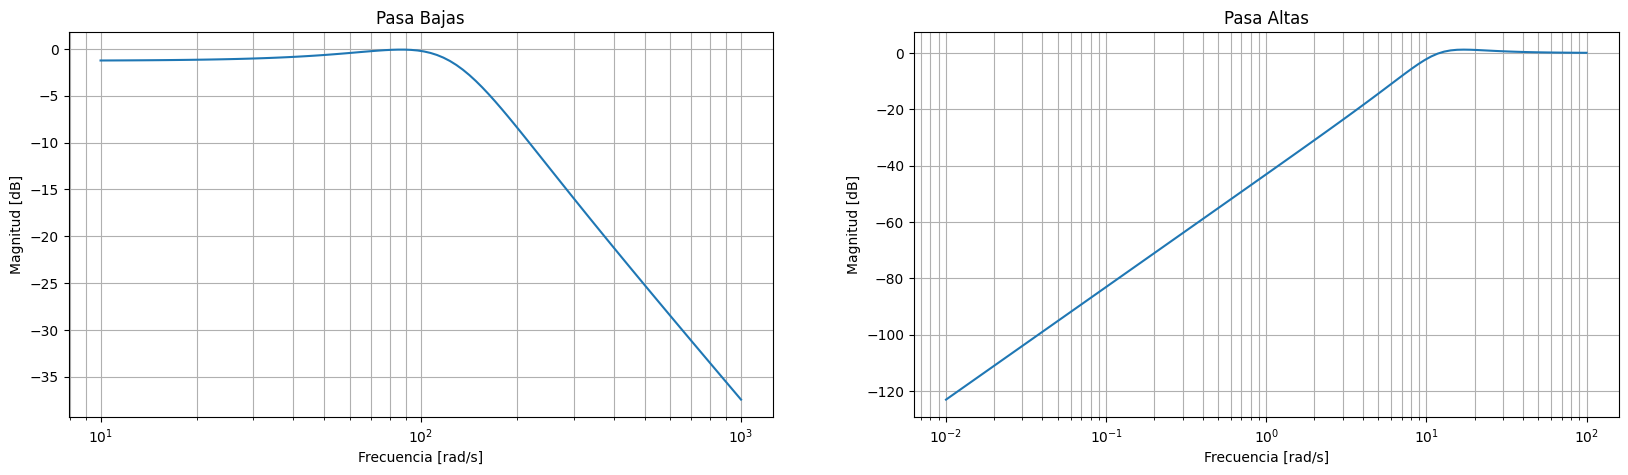

In [ ]:
H_Pbajas=signal.TransferFunction(1.33294390e+04,[1,1.25495493e+02,1.54307031e+04])
H_Paltas=signal.TransferFunction([1,0,0],[1,12.07727253,142.91150444])

frec_B,magnitud_B,fase_B=signal.bode(H_Pbajas)
frec_A,magnitud_A,fase_A=signal.bode(H_Paltas)


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title('Pasa Bajas')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
plt.semilogx(frec_B,magnitud_B)
#plt.ylim(35,45)#120
plt.grid(True, which="both")
plt.subplot(1,2,2)
plt.title('Pasa Altas')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
plt.semilogx(frec_A,magnitud_A)
plt.grid(True, which="both")

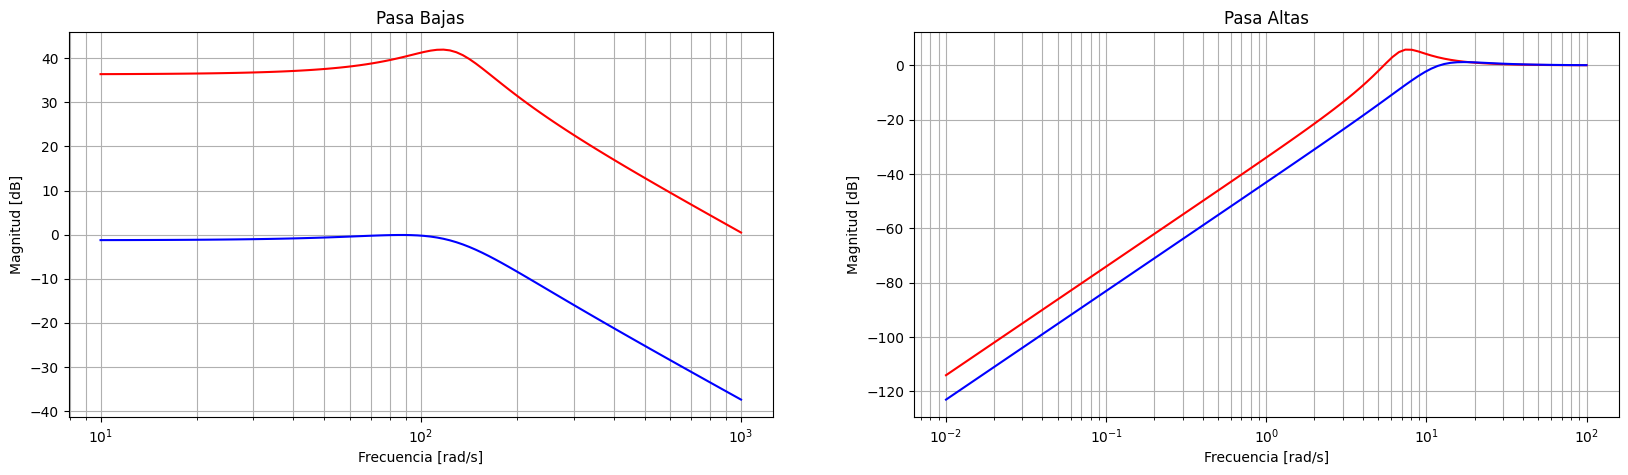

In [ ]:
#Elementos Pasa Bajas
R1=6500
Ra=12800
Rb=830000
C1=0.00000022
C2=0.0000068

#Elementos Pasa Altas
R3=54504
R4=781670
C5=0.00000068

H_PBajas_SK = signal.TransferFunction([(1+(Rb/Ra))/(C1*C2*R1**2)],[1,((1/R1)*((2/C1)-(Rb/(C2*Ra)))),1/(C1*C2*R1**2)])
H_PAltas_SK = signal.TransferFunction([1,0,0],[1,(2/(R4*C5)),(1/(R3*R4*C5**2))])

frec_PBajas_SK,magnitud_PBajas_SK,fase_PBajas_SK=signal.bode(H_PBajas_SK)
frec_PAltas_SK,magnitud_PAltas_SK,fase_PAltas_SK=signal.bode(H_PAltas_SK)

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
#plt.ylim(30,45)
plt.title('Pasa Bajas')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
plt.semilogx(frec_PBajas_SK,magnitud_PBajas_SK,color='r')
plt.semilogx(frec_B,magnitud_B,color='b')
plt.grid(True, which="both")
plt.subplot(1,2,2)
plt.title('Pasa Altas')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
plt.semilogx(frec_PAltas_SK,magnitud_PAltas_SK,color='r')
plt.semilogx(frec_A,magnitud_A,color='b')
plt.grid(True, which="both")

# **Librerías SPICE**

In [ ]:
#Instalación de librerías compatibles con PySpice v1.4.2
!apt install -q /content/drive/MyDrive/ColabNotebooks/SyS_II/1.libngspice0.deb
!apt install -q /content/drive/MyDrive/ColabNotebooks/SyS_II/2.libngspice0-dev.deb
!apt install -q /content/drive/MyDrive/ColabNotebooks/SyS_II/3.ngspice.deb
!apt install -q /content/drive/MyDrive/ColabNotebooks/SyS_II/4.tclspice.deb

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libncurses5 libtinfo5
The following NEW packages will be installed:
  libncurses5 libngspice0 libtinfo5
0 upgraded, 3 newly installed, 0 to remove and 35 not upgraded.
Need to get 207 kB/2,219 kB of archives.
After this operation, 8,261 kB of additional disk space will be used.
Get:1 /content/drive/MyDrive/ColabNotebooks/SyS_II/1.libngspice0.deb libngspice0 amd64 30.2-1~bpo9+1 [2,012 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libtinfo5 amd64 6.3-2ubuntu0.1 [100 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libncurses5 amd64 6.3-2ubuntu0.1 [107 kB]
Fetched 207 kB in 1s (293 kB/s)
Selecting previously unselected package libtinfo5:amd64.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../libtinfo5_6.3-2ubuntu0.1_amd64.deb ...
Unpacking libtinfo5:amd64 (6.

In [ ]:
#Instalación de PySpice v1.4.2
#El directorio debe coincidir en donde guardaron el archivo PySpice-1.4.2.tar.gz
!pip install -q /content/drive/MyDrive/ColabNotebooks/SyS_II/PySpice-1.4.2.tar.gz

  Preparing metadata (setup.py) ... done


In [ ]:
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Spice.Netlist import Circuit
from PySpice.Plot.BodeDiagram import bode_diagram
from PySpice.Unit import *

# **Simulación Secciones de Segundo Orden**

In [ ]:
MFB_Pbajas = Circuit('Multiple Feedback Pasa Bajas')

#Directorio del modelo LM741.mod
MFB_Pbajas.include('/content/drive/MyDrive/ColabNotebooks/SyS_II/LM741.mod')

MFB_Pbajas.SinusoidalVoltageSource('in', 1, 0, amplitude=1@u_V, frequency=10@u_Hz)
MFB_Pbajas.V('+',7,0,15@u_V)
MFB_Pbajas.V('-',0,4,15@u_V)
MFB_Pbajas.R('1',1,5,57750@u_Ohm)
MFB_Pbajas.R('2',5,2,19000@u_Ohm)
MFB_Pbajas.R('3',5,6,49854@u_Ohm)
MFB_Pbajas.R('4',3,0,53497@u_Ohm)
MFB_Pbajas.C('1',5,0,0.68@u_uF)
MFB_Pbajas.C('2',2,6,0.1@u_uF)
MFB_Pbajas.X('741','LM741/NS',3,2,7,4,6)

SubCircuitElement X741

In [ ]:
SK_Paltas = Circuit('Sallen-Key Pasa Altas')

#Directorio del modelo LM741.mod
SK_Paltas.include('/content/drive/MyDrive/ColabNotebooks/SyS_II/LM741.mod')

SK_Paltas.SinusoidalVoltageSource('in', 1, 0, amplitude=1@u_V, frequency=10@u_Hz)
SK_Paltas.V('+',7,0,15@u_V)
SK_Paltas.V('-',0,4,15@u_V)
SK_Paltas.R('1',5,6,192065@u_Ohm)
SK_Paltas.R('2',3,0,752728@u_Ohm)
SK_Paltas.C('1',1,5,0.22@u_uF)
SK_Paltas.C('2',5,3,0.22@u_uF)
SK_Paltas.X('741','LM741/NS',3,6,7,4,6)

SubCircuitElement X741

In [ ]:
simu_Pbajas = MFB_Pbajas.simulator(temperature=25, nominal_temperature=25)
data_Pbajas = simu_Pbajas.ac(start_frequency=1@u_Hz, stop_frequency=0.1@u_kHz,number_of_points=100, variation='dec')

simu_Paltas = SK_Paltas.simulator(temperature=25, nominal_temperature=25)
data_Paltas = simu_Paltas.ac(start_frequency=1@u_mHz, stop_frequency=0.1@u_kHz,number_of_points=100, variation='dec')

In [ ]:
Ω_Pbajas = data_Pbajas.frequency
H_jΩ_Pbajas = np.array(data_Pbajas.nodes['6']) / np.array(data_Pbajas.nodes['1'])
mag_Pbajas = 20*np.log10(np.abs(H_jΩ_Pbajas))
phase_Pbajas = np.angle(H_jΩ_Pbajas)

Ω_Paltas = data_Paltas.frequency
H_jΩ_Paltas = np.array(data_Paltas.nodes['6']) / np.array(data_Paltas.nodes['1'])
mag_Paltas = 20*np.log10(np.abs(H_jΩ_Paltas))
phase_Paltas = np.angle(H_jΩ_Paltas)

2025-07-24 04:52:54,287 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT
2025-07-24 04:52:54,290 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT
2025-07-24 04:52:54,329 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT
2025-07-24 04:52:54,331 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT


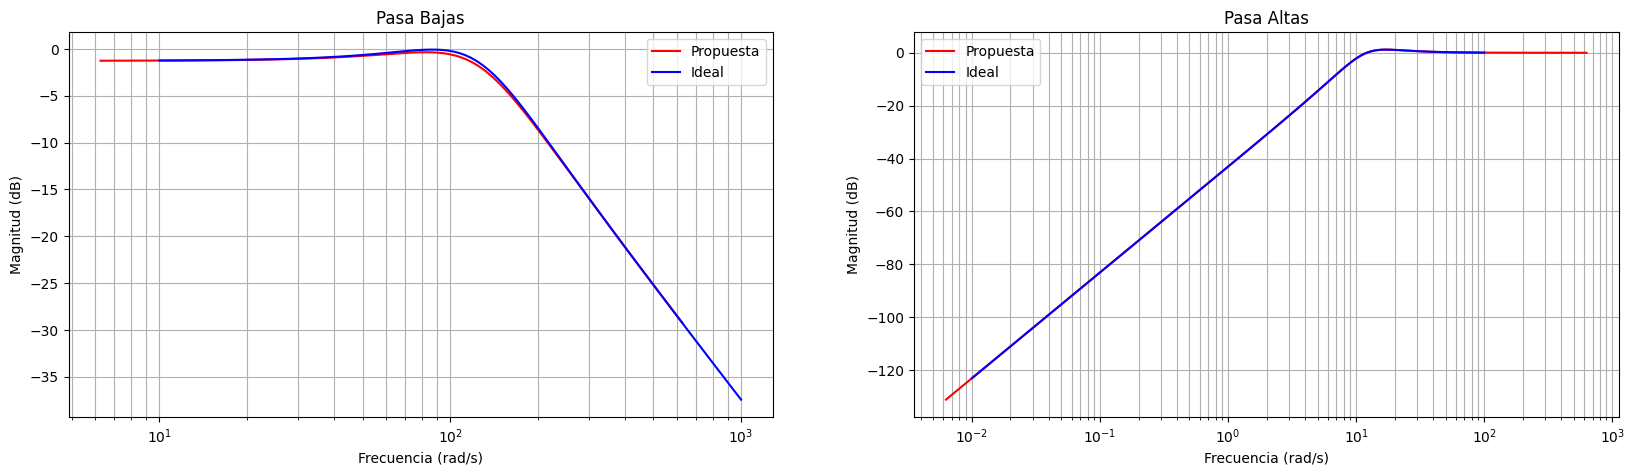

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title('Pasa Bajas')
plt.ylabel('Magnitud (dB)')
plt.xlabel('Frecuencia (rad/s)')
plt.semilogx(Ω_Pbajas*2*pi,mag_Pbajas,color='r', label='Propuesta')
plt.semilogx(frec_B,magnitud_B,color='b', label='Ideal')
plt.grid(True, which="both")
plt.legend()
plt.subplot(1,2,2)
plt.title('Pasa Altas')
plt.ylabel('Magnitud (dB)')
plt.xlabel('Frecuencia (rad/s)')
plt.semilogx(Ω_Paltas*2*pi,mag_Paltas,color='r', label='Propuesta')
plt.semilogx(frec_A,magnitud_A,color='b', label='Ideal')
plt.grid(True, which="both")
plt.legend()

# **Simulación Filtro Final**

In [ ]:
ChebyI_PBandas = Circuit('Chebyshev I Pasa Bandas')

#Directorio del modelo LM741.mod
ChebyI_PBandas.include('/content/drive/MyDrive/ColabNotebooks/SyS_II/LM741.mod')

ChebyI_PBandas.SinusoidalVoltageSource('in', 1, 0, amplitude=1@u_V, frequency=60@u_Hz)
ChebyI_PBandas.V('+',7,0,9@u_V)
ChebyI_PBandas.V('-',0,4,9@u_V)

ChebyI_PBandas.R('1',1,5,57750@u_Ohm)
ChebyI_PBandas.R('2',5,2,19000@u_Ohm)
ChebyI_PBandas.R('3',5,6,49854@u_Ohm)
ChebyI_PBandas.R('4',3,0,53497@u_Ohm)
ChebyI_PBandas.C('1',5,0,0.68@u_uF)
ChebyI_PBandas.C('2',2,6,0.1@u_uF)
ChebyI_PBandas.X('741','LM741/NS',3,2,7,4,6)

ChebyI_PBandas.R('5',51,61,192065@u_Ohm)
ChebyI_PBandas.R('6',31,0,752728@u_Ohm)
ChebyI_PBandas.C('3',6,51,0.22@u_uF)
ChebyI_PBandas.C('4',51,31,0.22@u_uF)
ChebyI_PBandas.X('741_1','LM741/NS',31,61,7,4,61)

SubCircuitElement X741_1

In [ ]:
simu_ChebyI_PBandas = ChebyI_PBandas.simulator(temperature=25, nominal_temperature=25)
data_ChebyI_PBandas = simu_ChebyI_PBandas.ac(start_frequency=1@u_mHz, stop_frequency=10@u_kHz,number_of_points=100, variation='dec')

In [ ]:
Ω_CPB = data_ChebyI_PBandas.frequency*2*pi
H_jΩ_CPB = np.array(data_ChebyI_PBandas.nodes['61']) / np.array(data_ChebyI_PBandas.nodes['1'])
mag_CPB = 20*np.log10(np.abs(H_jΩ_CPB))
phase_CPB = np.angle(H_jΩ_CPB)

2025-07-24 04:53:06,423 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT
2025-07-24 04:53:06,425 - PySpice.Probe.WaveForm.WaveForm.__array_ufunc__ - INFO - Conversion for <ufunc 'multiply'> is NEW_UNIT


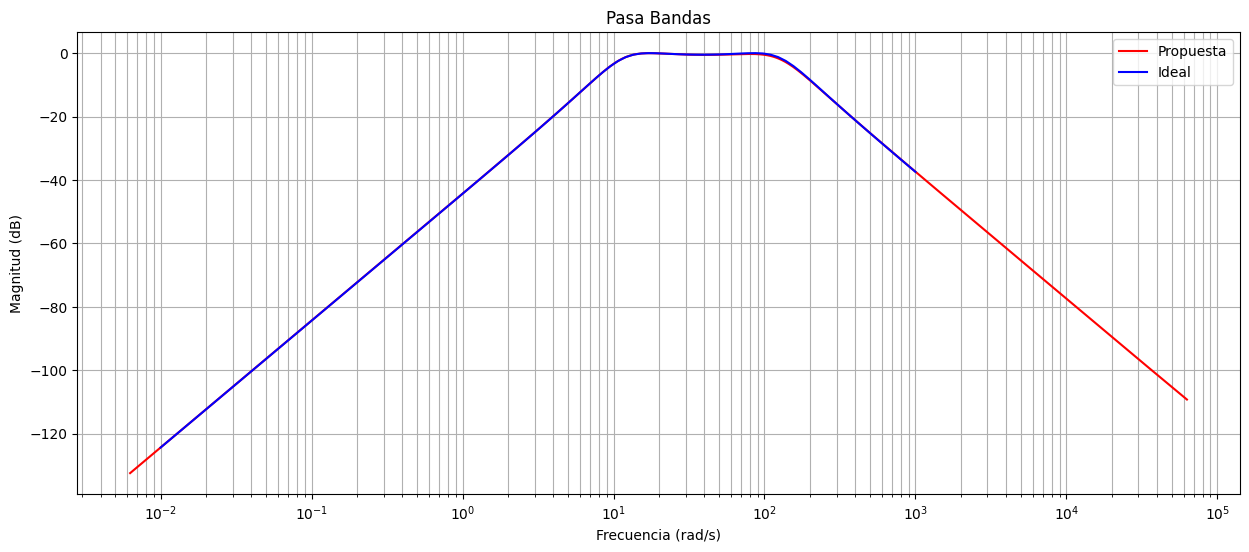

In [ ]:
plt.figure(figsize=(15,6))
#plt.ylim(-0.8,0.8)
#plt.xlim(1,300)
plt.title('Pasa Bandas')
plt.ylabel('Magnitud (dB)')
plt.xlabel('Frecuencia (rad/s)')
plt.semilogx(Ω_CPB,mag_CPB, color='r', label='Propuesta')
plt.semilogx(frec_cheby1,magnitud_cheby1, color='b', label='Ideal')
plt.legend()
plt.grid(True, which="both")

In [ ]:
#Estimación de la magnitud en las frecuencias de corte
Ω_CPB=np.array(Ω_CPB)
print(f'Magnitud [dB] en 7.5 rad/s:',mag_CPB[(Ω_CPB>13.4) & (Ω_CPB<13.6)])
print(f'Magnitud [dB] en 120 rad/s:',mag_CPB[(Ω_CPB>109) & (Ω_CPB<111)])

Magnitud [dB] en 7.5 rad/s: [-0.53498745]
Magnitud [dB] en 120 rad/s: [-0.8664744]


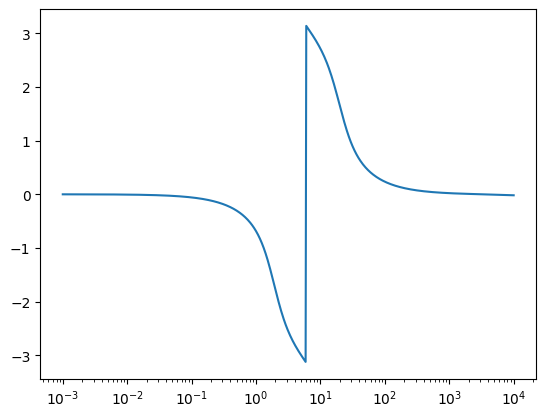

In [ ]:
plt.semilogx(Ω_CPB/(2*pi), phase_CPB)